In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from itertools import product
import warnings
warnings.filterwarnings('ignore')



ADF Statistic: -6.8225
p-value: 0.0000
Seasonal strength: 0.9921
Best SARIMA order: (1, 1, 2) Seasonal order: (0, 1, 1) AIC: 184.16


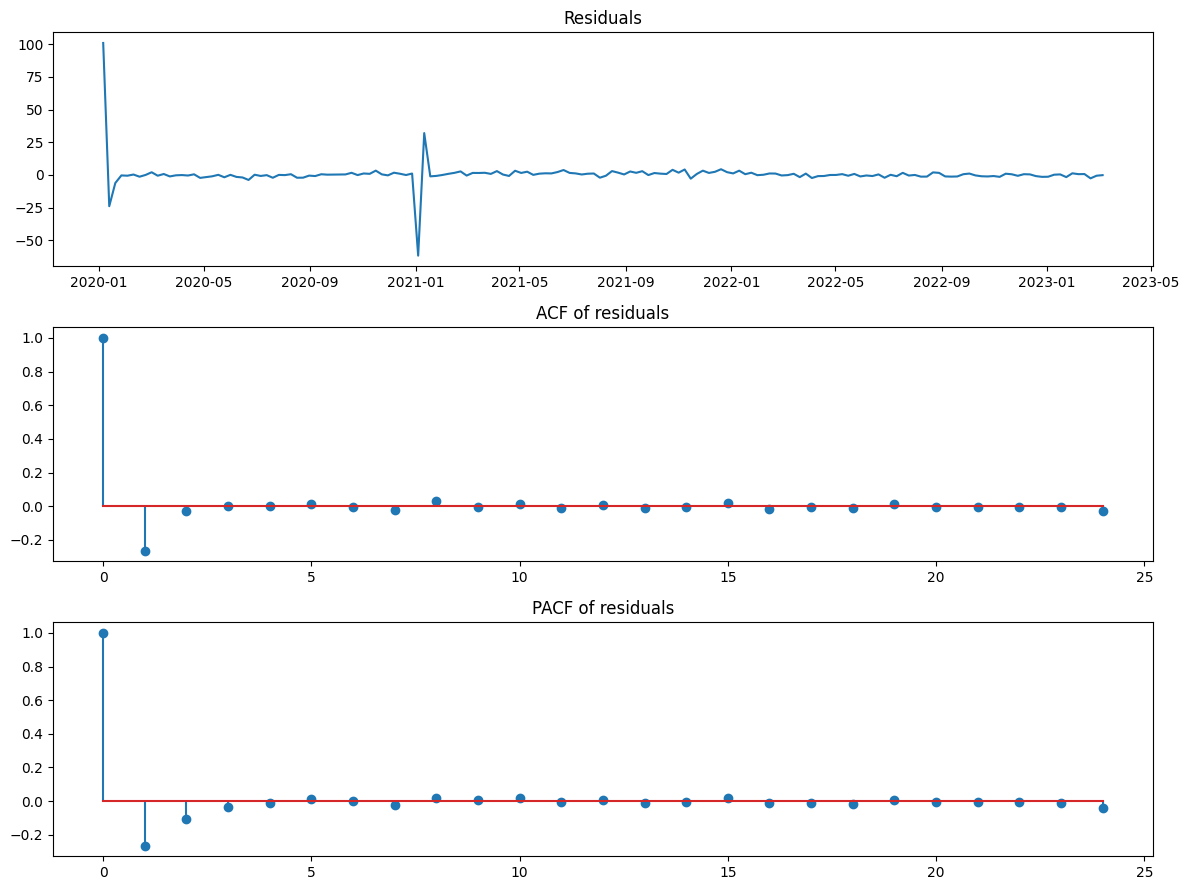

Ljung-Box test p-value at lag 24: 0.9723
Residuals appear to be white noise.


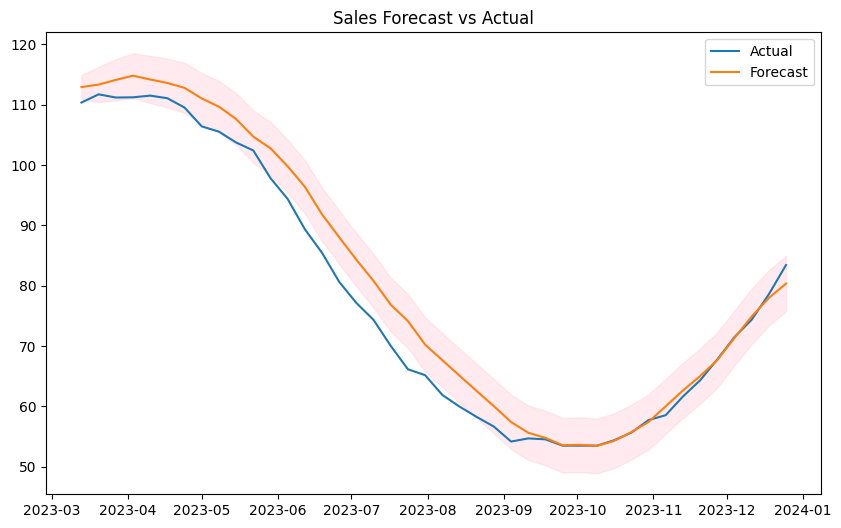

Test RMSE: 3.951
Test MAE: 3.097


(2023-03-13    112.933126
 2023-03-20    113.360200
 2023-03-27    114.135412
 2023-04-03    114.830211
 2023-04-10    114.201309
 2023-04-17    113.620280
 2023-04-24    112.807096
 2023-05-01    111.052028
 2023-05-08    109.689758
 2023-05-15    107.636342
 2023-05-22    104.725960
 2023-05-29    102.789872
 2023-06-05     99.802529
 2023-06-12     96.421150
 2023-06-19     91.840888
 2023-06-26     88.043202
 2023-07-03     84.315629
 2023-07-10     80.801695
 2023-07-17     76.865935
 2023-07-24     74.144991
 2023-07-31     70.246355
 2023-08-07     67.671142
 2023-08-14     65.102345
 2023-08-21     62.561658
 2023-08-28     60.048626
 2023-09-04     57.423392
 2023-09-11     55.642368
 2023-09-18     54.790398
 2023-09-25     53.568248
 2023-10-02     53.642481
 2023-10-09     53.458016
 2023-10-16     54.297141
 2023-10-23     55.747598
 2023-10-30     57.434718
 2023-11-06     60.028051
 2023-11-13     62.638986
 2023-11-20     65.033159
 2023-11-27     67.685474
 2023-12-04 

In [9]:
# --- Step 1: Data Prep ---
# Assume `sales` is a pd.Series indexed by datetime, and `exog` optional exogenous df aligned with sales
sales_series = pd.Series(np.random.randn(208).cumsum() + 100 + 30*np.sin(np.linspace(0, 8 * np.pi, 208)), index=pd.date_range(start='2020-01-01', periods=208, freq='W-MON'))  # Placeholder for actual sales data

exog = pd.DataFrame({
    'promo': np.random.randint(0, 2, size=208),
    'holiday': np.random.randint(0, 2, size=208)
}, index=sales_series.index)  # Placeholder for actual exogenous variables

def preprocess_sales(sales):
    # Fill missing values (example: forward fill then backward fill)
    sales = sales.ffill().bfill()
    
    # Handle outliers (winsorization example)
    lower = sales.quantile(0.01)
    upper = sales.quantile(0.99)
    sales_clipped = sales.clip(lower, upper)
    return sales_clipped

# --- Step 2: Stationarity Testing ---
def test_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] < 0.05  # True if stationary

def difference_until_stationary(series, max_diff=2):
    diff_series = series.copy()
    d = 0
    while d < max_diff:
        if test_stationarity(diff_series):
            return diff_series, d
        diff_series = diff_series.diff().dropna()
        d += 1
    return diff_series, d  # Return last if still non-stationary

# --- Step 3: Seasonality check ---
from statsmodels.tsa.seasonal import STL

def detect_seasonality(series, period):
    stl = STL(series, period=period)
    res = stl.fit()
    resid_std = np.std(res.resid)
    seasonal_strength = max(0, 1 - (np.var(res.resid) / np.var(series)))
    print(f'Seasonal strength: {seasonal_strength:.4f}')
    return seasonal_strength > 0.2  # heuristic threshold

# --- Step 4: Grid Search for SARIMA ---
def sarima_grid_search(y_train, exog_train=None, p_values=range(0,3),
                       d_values=[0,1], q_values=range(0,3),
                       P_values=range(0,2), D_values=[0,1],
                       Q_values=range(0,2), m=0):
    best_aic = np.inf
    best_order = None
    best_seasonal_order = None
    best_model = None
    
    for order in product(p_values, d_values, q_values):
        for seasonal_order in product(P_values, D_values, Q_values):
            try:
                if m == 0:
                    model = SARIMAX(y_train, order=order, exog=exog_train, enforce_stationarity=False,
                                    enforce_invertibility=False)
                else:
                    model = SARIMAX(y_train, order=order, seasonal_order=(seasonal_order[0], seasonal_order[1], seasonal_order[2], m),
                                    exog=exog_train, enforce_stationarity=False,
                                    enforce_invertibility=False)
                model_fit = model.fit(disp=False)
                
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = order
                    best_seasonal_order = seasonal_order if m > 0 else None
                    best_model = model_fit
            except Exception as e:
                continue
                
    print(f'Best SARIMA order: {best_order} Seasonal order: {best_seasonal_order} AIC: {best_aic:.2f}')
    return best_model, best_order, best_seasonal_order

# --- Step 5: Train-Test Split ---
def train_test_split(series, test_ratio=0.2):
    n = len(series)
    train_end = int(n * (1 - test_ratio))
    train = series.iloc[:train_end]
    test = series.iloc[train_end:]
    return train, test

# --- Step 6: Residual Diagnostics ---
def residual_diagnostics(model_fit, lags=24):
    resid = model_fit.resid
    fig, axes = plt.subplots(3,1, figsize=(12,9))
    
    axes[0].plot(resid)
    axes[0].set_title('Residuals')
    
    acf_vals = acf(resid, nlags=lags)
    axes[1].stem(range(len(acf_vals)), acf_vals)
    axes[1].set_title('ACF of residuals')
    
    pacf_vals = pacf(resid, nlags=lags)
    axes[2].stem(range(len(pacf_vals)), pacf_vals)
    axes[2].set_title('PACF of residuals')
    
    plt.tight_layout()
    plt.show()
    
    lb_test = acorr_ljungbox(resid, lags=[lags], return_df=True)
    print(f'Ljung-Box test p-value at lag {lags}: {lb_test["lb_pvalue"].values[0]:.4f}')
    if lb_test["lb_pvalue"].values[0] > 0.05:
        print("Residuals appear to be white noise.")
    else:
        print("Residual autocorrelation detected.")    

# --- Step 7: Forecast and Evaluate ---
def forecast_and_evaluate(model_fit, steps, y_test, exog_test=None):
    forecast_res = model_fit.get_forecast(steps=steps, exog=exog_test)
    forecast_mean = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int()
    
    plt.figure(figsize=(10,6))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, forecast_mean, label='Forecast')
    plt.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
    plt.legend()
    plt.title('Sales Forecast vs Actual')
    
    plt.show()
    
    rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
    mae = mean_absolute_error(y_test, forecast_mean)
    print(f'Test RMSE: {rmse:.3f}')
    print(f'Test MAE: {mae:.3f}')
    
    return forecast_mean, conf_int

# ====== Example usage ======

# Assume sales data and optional exog variables have been loaded to:
# sales_series (pd.Series indexed by datetime), exog_vars (pd.DataFrame aligned with sales_series)

# Preprocess sales
sales_clean = preprocess_sales(sales_series)

# Train test split
train, test = train_test_split(sales_clean)

# Stationarity & differencing (use on training only)
stationary_train, d = difference_until_stationary(train)

# Detect seasonality (e.g. monthly with m=12, weekly with m=7)
seasonal_period = 52  # Adjust based on data frequency
has_seasonality = detect_seasonality(train, seasonal_period)
m = seasonal_period if has_seasonality else 0

# Grid search SARIMA parameters
best_model, best_order, best_seasonal_order = sarima_grid_search(train, exog_train=None, m=m)

# Diagnostics
residual_diagnostics(best_model)

# Forecast and evaluate
steps = len(test)
forecast_and_evaluate(best_model, steps, test, exog_test=None)